In [189]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt
from astrometry_equations import angular_distance
import seaborn as sns

In [205]:
# Bugfixing, discretization/rouding errors going on in np.arccos
def angular_distance(ra_a, dec_a, ra_b, dec_b, unit='radians'):
    """Calculates the angular distance between point A and point B without any assumptions
    For the equation, and its derivation see https://en.wikipedia.org/wiki/Angular_distance#General_case
    IMPORTANT: ra and dec are expected to be in RADIANS, if they're not use unit to specify"""

    print(np.min(ra_a))
    u, c = np.unique(ra_a, return_counts=True)
    print(c)

    if unit =='radians':
        pass
    elif unit=='degrees':
        # Convert degrees to radians
        [ra_a, dec_a, ra_b, dec_b] = np.radians([ra_a, dec_a, ra_b, dec_b])
    else:
        raise ValueError(f"Unit {unit} is not recognized")

    u, c = np.unique(ra_a, return_counts=True)
    print(c)

    sin_factor = np.sin(dec_a)*np.sin(dec_b)
    print(np.min(sin_factor))
    u, c = np.unique(sin_factor, return_counts=True)
    print(c)

    cos_factor = np.cos(dec_a)*np.cos(dec_b)*np.cos(ra_a-ra_b)

    print(np.min(cos_factor))
    u, c = np.unique(cos_factor, return_counts=True)
    print(c)

    theta = np.arccos(sin_factor + cos_factor)
    print(np.min(theta))
    u, c = np.unique(theta, return_counts=True)
    print(u)
    print(c)

    return theta

In [105]:
username = 'rkievit'
Gaia.login(user=username)

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK


# Study of Gaia DR3 M_G < 12 Selection

In [80]:
job = Gaia.launch_job_async("SELECT gaia12.*, gaia.bp_rp\
                            FROM user_rkievit.gaia_sel12_prop as gaia12 \
                            JOIN gaiadr3.gaia_source_lite AS gaia USING (source_id)")

INFO: Query finished. [astroquery.utils.tap.core]


In [81]:
r = job.get_results()


In [182]:
plx_mask = ~r['parallax'].mask # Hotfix because we did not filter out the Gaia objects without plx/pm information

In [206]:
theta = angular_distance(r['ra'][plx_mask], r['dec'][plx_mask], r['ra_prop'][plx_mask], r['dec_prop'][plx_mask],unit='degrees')
theta_as = 3600. * np.degrees(theta)

0.0002052024238820092
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
-2.2061251818804694e-12
[1 1 1 ... 1 1 1]
3.7072554543624997e-06
[1 1 1 ... 1 1 1]
0.0
[0.00000000e+00 1.49011612e-08 2.10734243e-08 ... 8.47117440e-04
 1.03888153e-03 1.24520720e-03]
[477 544 989 ...   1   1   1]


In [201]:
np.unique(theta, return_counts=True)

(array([0.00000000e+00, 1.49011612e-08, 2.10734243e-08, ...,
        8.47117440e-04, 1.03888153e-03, 1.24520720e-03]),
 array([477, 544, 989, ...,   1,   1,   1], dtype=int64))

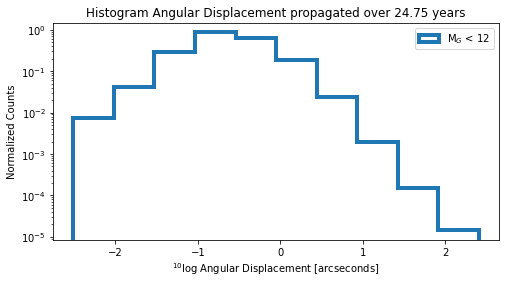

In [149]:
# Histogram of Displacement
fig, ax = plt.subplots(1,1, figsize=(8,4))

mask = theta_as > 0
ax.hist(np.log10(theta_as[mask]), density=True, log=True, histtype='step', lw=4, label=r"M$_G$ < 12")

ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Histogram Angular Displacement propagated over 24.75 years")

plt.legend()
plt.savefig('../../figures/bprop_theta_gaia12',bbox_inches='tight', transparent=True)
plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/2187731387.py:5: RuntimeWarning: divide by zero encountered in log10
  ax.hexbin(np.log10(theta_as), np.log10(nu), bins='log', mincnt=1, cmap='jet', label=r"M$_G$ < 12") # Density distribution


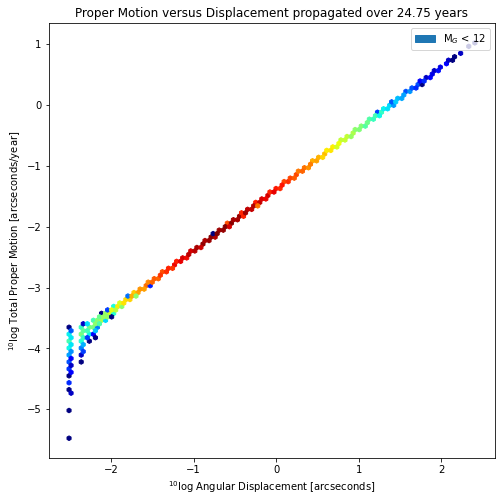

In [147]:
# Density Distribution of Proper Motion vs. Displacement
fig, ax = plt.subplots(1,1, figsize=(8,8))

nu = np.sqrt((r['pmra']**2) + r['pmdec']**2)/1e3
ax.hexbin(np.log10(theta_as), np.log10(nu), bins='log', mincnt=1, cmap='jet', label=r"M$_G$ < 12") # Density distribution

ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel(r"$^{10}$log Total Proper Motion [arcseconds/year]")
ax.set_title("Proper Motion versus Displacement propagated over 24.75 years")

plt.legend()
plt.savefig('../../figures/bprop_theta_nu_gaia12',bbox_inches='tight',transparent=True)
plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/2342157593.py:5: RuntimeWarning: divide by zero encountered in log10
  nu_theta = ax.scatter(np.log10(theta_as), np.log10(nu), c=r['dec'], s=2, label=r"M$_G$ < 12", cmap='jet')


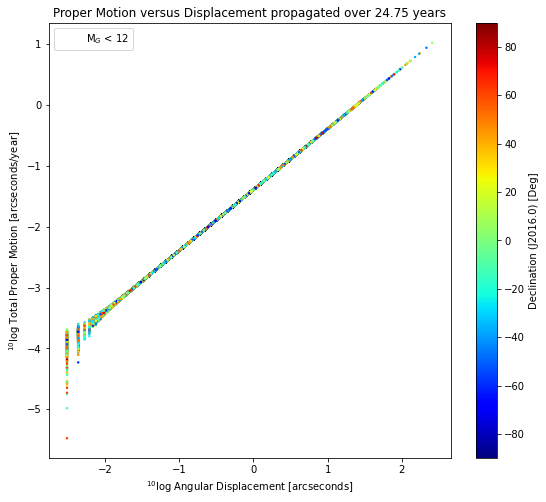

In [152]:
# Distribution of Proper Motion vs. Displacement coded by Declination
fig, ax = plt.subplots(1,1, figsize=(9,8))

nu = np.sqrt((r['pmra']**2) + r['pmdec']**2)/1e3
nu_theta = ax.scatter(np.log10(theta_as), np.log10(nu), c=r['dec'], s=2, label=r"M$_G$ < 12", cmap='jet')
cb = plt.colorbar(nu_theta)

cb.set_label("Declination (J2016.0) [Deg]")
ax.set_xlabel(r"$^{10}$log Angular Displacement [arcseconds]")
ax.set_ylabel(r"$^{10}$log Total Proper Motion [arcseconds/year]")
ax.set_title("Proper Motion versus Displacement propagated over 24.75 years")

plt.legend()
plt.savefig('../../figures/bprop_theta_nu_gaia12_dec',bbox_inches='tight',transparent=True)
plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/2644966605.py:3: RuntimeWarning: invalid value encountered in log10
  abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/2644966605.py:5: RuntimeWarning: divide by zero encountered in log10
  cmd = ax.scatter(r['bp_rp'], abs_mag, c=np.log10(theta_as), s=2, cmap='jet')


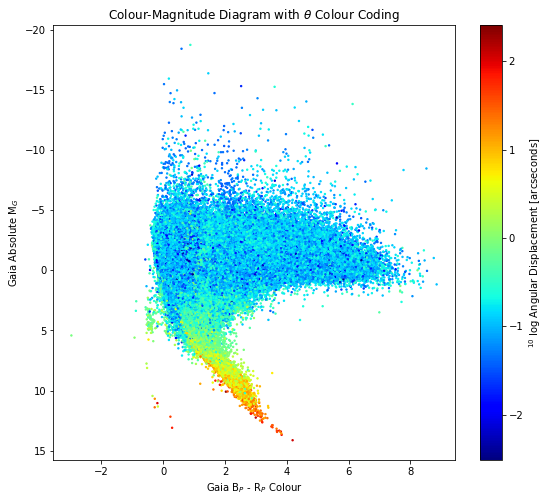

In [150]:
fig, ax = plt.subplots(1,1, figsize=(9,8))

abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)

cmd = ax.scatter(r['bp_rp'], abs_mag, c=np.log10(theta_as), s=2, cmap='jet')
cb = plt.colorbar(cmd)

cb.set_label(r"$^{10}$ log Angular Displacement [arcseconds]")
ax.set_xlabel(r"Gaia B$_P$ - R$_P$ Colour")
ax.set_ylabel(r"Gaia Absolute M$_G$")
ax.set_title(r"Colour-Magnitude Diagram with $\theta$ Colour Coding")

ax.invert_yaxis()

big_xlim = ax.get_xlim()
big_ylim = ax.get_ylim()

plt.savefig('../../figures/bprop_cmd_gaia12',bbox_inches='tight',transparent=True)
#ax.hexbin(r_c['bp_rp'], abs_mag, bins='log', mincnt=1, label=r'M$_G$ < 12', cmap='jet')

C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/1338840717.py:3: RuntimeWarning: invalid value encountered in log10
  abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/1338840717.py:5: RuntimeWarning: divide by zero encountered in log10
  mask = np.log10(theta_as) < -1.5
C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/1338840717.py:7: RuntimeWarning: divide by zero encountered in log10
  cmd = ax.scatter(r['bp_rp'][mask], abs_mag[mask], c=np.log10(theta_as)[mask], s=4, cmap='jet')


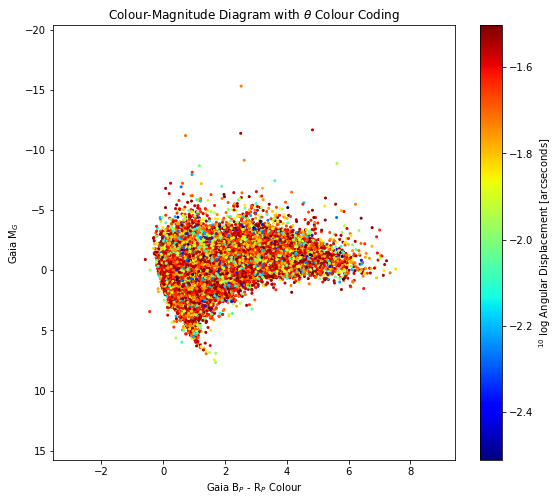

In [151]:
fig, ax = plt.subplots(1,1, figsize=(9,8))

abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)

mask = np.log10(theta_as) < -1.5

cmd = ax.scatter(r['bp_rp'][mask], abs_mag[mask], c=np.log10(theta_as)[mask], s=4, cmap='jet')
cb = plt.colorbar(cmd)

cb.set_label(r"$^{10}$ log Angular Displacement [arcseconds]")
ax.set_xlabel(r"Gaia B$_P$ - R$_P$ Colour")
ax.set_ylabel(r"Gaia M$_G$")
ax.set_title(r"Colour-Magnitude Diagram with $\theta$ Colour Coding")

ax.invert_yaxis()

ax.set_xlim(big_xlim)
ax.set_ylim(big_ylim)

plt.savefig('../../figures/bprop_cmd_gaia12_masked0',bbox_inches='tight',transparent=True)

C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/1927950552.py:3: RuntimeWarning: invalid value encountered in log10
  abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/1927950552.py:5: RuntimeWarning: divide by zero encountered in log10
  cmd = ax.scatter(r['bp_rp'], abs_mag, c=np.log10(theta_as), s=2)
C:\Users\Rens\AppData\Local\Temp/ipykernel_12820/1927950552.py:6: RuntimeWarning: divide by zero encountered in log10
  cmd = ax.scatter(r['bp_rp'][mask], abs_mag[mask], c=np.log10(theta_as)[mask], s=4, cmap='jet')


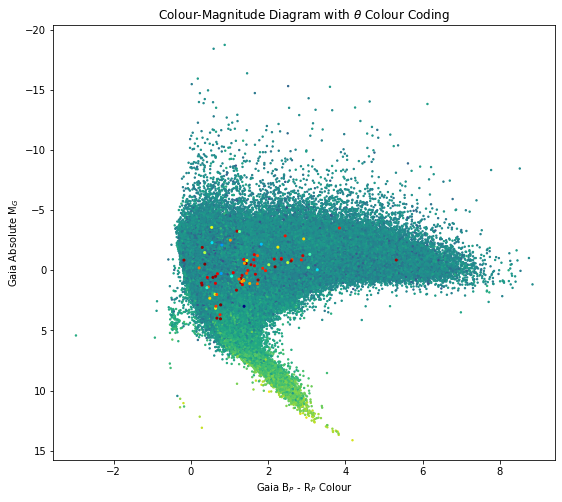

In [102]:
fig, ax = plt.subplots(1,1, figsize=(9,8))

abs_mag = r['phot_g_mean_mag'] + 5.*(np.log10(r['parallax']/1e3) + 1.)

cmd = ax.scatter(r['bp_rp'], abs_mag, c=np.log10(theta_as), s=2)
cmd = ax.scatter(r['bp_rp'][mask], abs_mag[mask], c=np.log10(theta_as)[mask], s=4, cmap='jet')
#cb = plt.colorbar(cmd)

cb.set_label(r"$^{10}$ log Angular Displacement [arcseconds]")
ax.set_xlabel(r"Gaia B$_P$ - R$_P$ Colour")
ax.set_ylabel(r"Gaia Absolute M$_G$")
ax.set_title(r"Colour-Magnitude Diagram with $\theta$ Colour Coding")

ax.invert_yaxis()

big_xlim = ax.get_xlim()
big_ylim = ax.get_ylim()

plt.savefig('../../figures/bprop_cmd_gaia12_combined',bbox_inches='tight',transparent=True)

# Gaia DR3 - Hipparcos2 Simple Crossmatch for M_G < 12

In [106]:
job_xm = Gaia.launch_job_async("SELECT * \
                               FROM user_rkievit.xm_hipp_gaia12")
r_xm = job_xm.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [122]:
gaia_id = r_xm['gaia_sel12_prop_gaia_sel12_prop_oid']
hipp_id = r_xm['hipp_small_hipp_small_oid']
sep = r_xm['separation']

In [116]:
print(f"The cross-match between Hipp2 and Gaia DR3 resulted in {len(gaia_id)} matches.")
u_g, c_g = np.unique(gaia_id, return_counts=True) #u are all unique instances, c is the amount of counts for each unique item in u
print(f"Duplicate Gaia objects: {len(u_g[c_g>1])}")

u_h, c_h =  np.unique(hipp_id, return_counts=True)
print(f"Duplicate Hipp objects: {len(u_h[c_h>1])}")

The cross-match between Hipp2 and Gaia DR3 resulted in 156 matches.
Duplicate Gaia objects: 0
Duplicate Hipp objects: 0


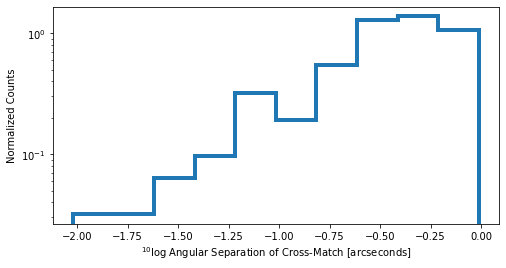

In [128]:
fig, ax = plt.subplots(1,1,figsize=(8,4))

ax.hist(np.log10(sep*3600), log=True,histtype='step',density=True,lw=4)

ax.set_xlabel(r"$^{10}$log Angular Separation of Cross-Match [arcseconds]")
ax.set_ylabel("Normalized Counts")

plt.show()